# 10. Modular RAG 순차 파이프라인

## 학습 목표

- LangGraph Basic RAG를 Modular RAG로 확장한다.
- 질문 분류, 검색, 근거 정리, 답변 생성, 검증을 각각 노드로 분리한다.
- 아직 `src` 파일을 사용하지 않고 노트북 안에서 전체 구조를 구현한다.

## 공통 전제

- 실습 데이터: `../data/공직자_민원응대_핵심_매뉴얼.pdf`
- 기본 모델: `gpt-4o-mini`
- 기본 임베딩 모델: `text-embedding-3-small`
- 벡터DB: Qdrant 로컬 인메모리 모드

> 이 노트북은 `src` 파일을 import하지 않고, 노트북 안의 코드만으로 실행되도록 구성한다.

In [ ]:
from typing_extensions import TypedDict, NotRequired

from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../../.env")


True

## 1. 벡터스토어 객체 생성

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore

QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "civil_complaint_manual_medium"

EMBEDDING_MODEL = "text-embedding-3-small"

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
)

## 2. 질문 유형 분류 함수

처음에는 LLM 분류가 아니라 규칙 기반 분류로 단순하게 구현한다.

In [ ]:
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END

def classify_question(question: str) -> dict:
    rules = [
        ("repeat_call", ["반복", "계속 전화", "같은 말", "동일"]),
        ("long_call", ["장시간", "오래", "권장시간", "20분", "15분"]),
        ("supervisor_request", ["상급자", "기관장", "부서장", "팀장"]),
        ("phone_abuse", ["전화", "욕설", "폭언", "협박", "성희롱"]),
        ("face_to_face_abuse", ["대면", "방문", "욕설", "폭언"]),
        ("violence", ["폭행", "때리", "물리"]),
        ("property_damage", ["파손", "부수", "집기", "물품"]),
        ("dangerous_object", ["위험물", "흉기", "칼", "인화물질", "불"]),
        ("online_abuse", ["온라인", "문서", "인터넷"]),
        ("recovery_protection", ["보호", "휴식", "휴가", "심리", "치료"]),
        ("legal_basis", ["법", "처벌", "형량", "고소", "고발"]),
    ]

    for case_type, keywords in rules:
        if any(keyword in question for keyword in keywords):
            return {
                "case_type": case_type,
                "rewritten_query": rewrite_query(question, case_type)
            }

    return {
        "case_type": "general",
        "rewritten_query": question
    }


def rewrite_query(question: str, case_type: str) -> str:
    expansions = {
        "repeat_call": "정당한 사유 없는 반복전화 동일민원 통화 종료 상담 종료",
        "long_call": "정당한 사유 없는 장시간 통화 권장시간 상담 종료",
        "supervisor_request": "상급자 기관장 통화 요구 실무자 대응 담당 팀장 대응",
        "phone_abuse": "전화응대 폭언 욕설 협박 성희롱 증거 확보 통화 종료",
        "face_to_face_abuse": "대면응대 폭언 욕설 협박 성희롱 녹화 녹음 상담 종료",
        "violence": "대면응대 폭행 비상대응팀 경찰 신고 피해공무원 분리",
        "property_damage": "집기 물품 파손 공용물건손상 경찰 신고 비상대응팀",
        "dangerous_object": "위험물 소지 흉기 인화물질 경찰 신고 119 신고 대피",
        "online_abuse": "온라인 문서민원 폭언 경고공문 부서장 보고",
        "recovery_protection": "민원담당자 회복 보호조치 휴식 휴가 심리상담 치료 지원",
        "legal_basis": "위법행위 유형별 적용 법률 형법 경범죄처벌법 공무집행방해",
    }

    return f"{question}\n검색 키워드: {expansions.get(case_type, '')}".strip()

## 3. 프롬프트 구성

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 근거 정리 프롬프트
evidence_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
검색된 문단에서 질문 답변에 필요한 핵심 근거만 정리하세요.
문단에 없는 내용은 추가하지 마세요.
'''),
    ("human", '''
질문:
{question}

검색 문단:
{context}
''')
])

# 답변 생성 프롬프트
answer_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 공직자 민원응대 매뉴얼 기반 업무지원 AI입니다.
반드시 제공된 근거에 기반하여 답변하세요.
매뉴얼에 없는 내용은 추측하지 마세요.

답변 형식:
1. 핵심 대응
2. 단계별 조치
3. 사용할 수 있는 안내 표현
4. 담당자 보호조치
5. 주의사항
'''),
    ("human", '''
질문:
{question}

근거:
{evidence}
''')
])

# 답변 검증 프롬프트
validation_prompt = ChatPromptTemplate.from_messages([
    ("system", '''
당신은 RAG 답변 검토자입니다.
답변이 근거에 기반하는지 검토하세요.
결과는 '충분', '부분충분', '부족' 중 하나로 시작하세요.
'''),
    ("human", '''
질문:
{question}

검색 근거:
{context}

답변:
{answer}
''')
])

evidence_chain = evidence_prompt | llm | StrOutputParser()
answer_chain = answer_prompt | llm | StrOutputParser()
validation_chain = validation_prompt | llm | StrOutputParser()

## 4. 유틸 함수

In [15]:
def format_docs(docs: list[Document]) -> str:
    formatted = []

    for i, doc in enumerate(docs, start=1):
        formatted.append(
            f"[근거 {i}] page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(formatted)

## 5. State 정의

In [16]:
class ModularRAGState(TypedDict):
    question: str
    case_type: NotRequired[str]
    rewritten_query: NotRequired[str]
    documents: NotRequired[list[Document]]
    context: NotRequired[str]
    evidence: NotRequired[str]
    answer: NotRequired[str]
    validation: NotRequired[str]

## 6. Node 정의

In [ ]:
# ── 노드 1: 질문 분류 ─────────────────────────────────
def classify_question_node(state: ModularRAGState) -> dict:
    result = classify_question(state["question"])

    return {
        "case_type": result["case_type"],
        "rewritten_query": result["rewritten_query"]
    }

# ── 노드 2: 매뉴얼 검색 ──────────────────────────────
def retrieve_manual_node(state: ModularRAGState) -> dict:
    query = state.get("rewritten_query") or state["question"]
    docs = vector_store.similarity_search(query, k=4)
    context = format_docs(docs)

    return {
        "documents": docs,
        "context": context
    }

# ── 노드 3: 근거 정리 ─────────────────────────────────
def organize_evidence_node(state: ModularRAGState) -> dict:
    evidence = evidence_chain.invoke({
        "question": state["question"],
        "context": state["context"]
    })

    return {
        "evidence": evidence
    }

# ── 노드 4: 답변 생성 ─────────────────────────────────
def generate_answer_node(state: ModularRAGState) -> dict:
    answer = answer_chain.invoke({
        "question": state["question"],
        "evidence": state["evidence"]
    })

    return {
        "answer": answer
    }

# ── 노드 5: 답변 검증 ─────────────────────────────────
def validate_answer_node(state: ModularRAGState) -> dict:
    validation = validation_chain.invoke({
        "question": state["question"],
        "context": state["context"],
        "answer": state["answer"]
    })

    return {
        "validation": validation
    }

## 7. Graph 구성

In [ ]:
graph = StateGraph(ModularRAGState)

graph.add_node("classify_question", classify_question_node)
graph.add_node("retrieve_manual", retrieve_manual_node)
graph.add_node("organize_evidence", organize_evidence_node)
graph.add_node("generate_answer", generate_answer_node)
graph.add_node("validate_answer", validate_answer_node)

graph.add_edge(START, "classify_question")
graph.add_edge("classify_question", "retrieve_manual")
graph.add_edge("retrieve_manual", "organize_evidence")
graph.add_edge("organize_evidence", "generate_answer")
graph.add_edge("generate_answer", "validate_answer")
graph.add_edge("validate_answer", END)

app = graph.compile()

### 그래프 시각화

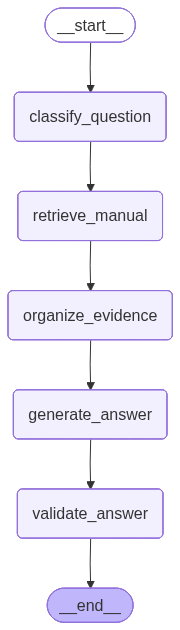

In [19]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 8. 실행

In [ ]:
question = "대면 민원 중 폭행이 발생하면 어떻게 해야 하나요?"

result = app.invoke({
    "question": question
})

print("[질문 유형]")
print(result["case_type"])

print("\n[검색 질의]")
print(result["rewritten_query"])

print("\n[근거 정리]")
print(result["evidence"])

print("\n[답변]")
print(result["answer"])

print("\n[검증]")
print(result["validation"])

[질문 유형]
face_to_face_abuse

[검색 질의]
대면 민원 중 폭행이 발생하면 어떻게 해야 하나요?
검색 키워드: 대면응대 폭언 욕설 협박 성희롱 녹화 녹음 상담 종료

[근거 정리]
1. **즉시 녹화(음) 실시**: 폭행 발생 시 즉시 녹화(음)를 실시하고, 비상대응팀에 신속히 대응 요청.
2. **민원인 진정 및 경고**: 팀장이 민원인을 진정시키고 경고 후 퇴거 조치, 필요 시 경찰과 동행.
3. **경찰 신고**: 폭행이 예상되거나 발생할 경우 즉시 경찰에 신고.
4. **담당자 분리조치**: 팀원은 담당자를 분리하고, 안전요원 호출 및 피해자 상태 확인.
5. **법적 조치 협의**: 부서장이 전담부서와 협의하여 법적 조치 진행.
6. **피해자 면담 및 휴식 조치**: 피해 직원 면담 후 60분 이내 휴식 부여.
7. **증거 확보**: 통화 시 녹음하여 위법행위 증거 확보 및 법적 조치 가능성 고지.
8. **경고문 발송**: 폭력을 행사하지 않고 진정된 경우 서면 경고문 발송.

[답변]
1. **핵심 대응**: 폭행 발생 시 즉시 녹화 및 비상대응팀에 요청, 민원인 진정 및 퇴거 조치, 경찰 신고, 담당자 분리 및 피해자 상태 확인.

2. **단계별 조치**:
   - **즉시 녹화(음) 실시**: 폭행이 발생하면 즉시 녹화(음)를 시작합니다.
   - **비상대응팀 요청**: 녹화와 동시에 비상대응팀에 신속히 대응 요청합니다.
   - **민원인 진정 및 경고**: 팀장이 민원인을 진정시키고 경고 후 퇴거 조치를 취합니다. 필요 시 경찰과 동행합니다.
   - **경찰 신고**: 폭행이 예상되거나 발생할 경우 즉시 경찰에 신고합니다.
   - **담당자 분리조치**: 팀원은 담당자를 분리하고, 안전요원을 호출하여 피해자의 상태를 확인합니다.
   - **법적 조치 협의**: 부서장이 전담부서와 협의하여 법적 조치를 진행합니다.
   - **피해자 면담 및 휴식 조치**: 피해 직원과 면담 후 60분 이내에 휴식을 부여합니다

## 핵심 정리

```text
START
→ classify_question
→ retrieve_manual
→ organize_evidence
→ generate_answer
→ validate_answer
→ END
```

- Modular RAG는 기능을 모듈로 분리한다.
- 질문 분류, 검색, 근거 정리, 답변 생성, 검증을 각각 독립 노드로 구성한다.